# Part 1 #

**Data Exploration**

In [34]:
# Import libraries
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from skimage.feature import hog
import cv2
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import random
import pickle

In [35]:
# Open and load Zambali Rice Dataset
dataset_path = "RiceLeafsDisease"
categories = sorted(os.listdir(dataset_path)) # Shuffle categories

data = []

for category in categories:
    path = os.path.join(dataset_path, category)
    for img in os.listdir(path):
        data.append([img, category])

df = pd.DataFrame(data, columns=["filename", "label"])

In [36]:
# Display first 10 rows
print(df.head(10))

# Data types
print(df.dtypes)

# Summary statistics
print(df['label'].value_counts())

                          filename             label
0    bacterial_leaf_blight (1).JPG  BACTERIAL_BLIGHT
1   bacterial_leaf_blight (10).JPG  BACTERIAL_BLIGHT
2  bacterial_leaf_blight (100).JPG  BACTERIAL_BLIGHT
3  bacterial_leaf_blight (101).JPG  BACTERIAL_BLIGHT
4  bacterial_leaf_blight (102).JPG  BACTERIAL_BLIGHT
5  bacterial_leaf_blight (103).JPG  BACTERIAL_BLIGHT
6  bacterial_leaf_blight (104).JPG  BACTERIAL_BLIGHT
7  bacterial_leaf_blight (105).JPG  BACTERIAL_BLIGHT
8  bacterial_leaf_blight (106).JPG  BACTERIAL_BLIGHT
9  bacterial_leaf_blight (107).JPG  BACTERIAL_BLIGHT
filename    str
label       str
dtype: object
label
BACTERIAL_BLIGHT    350
BROWN_SPOT          350
HEALTHY             350
LEAF_BLAST          350
LEAF_SCALD          350
NOT_A_RICE_LEAF     350
Name: count, dtype: int64


**Data Cleaning**

In [37]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Verify dataset size
print("Total samples:", len(df))

filename    0
label       0
dtype: int64
Total samples: 2100


***Key expectations for the dataset***\
*- No missing values expected (image dataset)*\
*- Duplicates removed if any repeated filenames*

**Data Preprocessing**

In [38]:
# Encode labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

# Train-test split
train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df['label_encoded'], random_state=42
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 1680
Test size: 420


# Part 2 #

**Image Preprocessing**

In [39]:
IMG_SIZE = 64

# Image processing (raw pixels only)
def process_images(df):
    X, y, images = [], [], []
    
    for _, row in df.iterrows():
        img_path = os.path.join(dataset_path, row['label'], row['filename'])
        
        img = cv2.imread(img_path)
        if img is None:
            continue
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, (IMG_SIZE, IMG_SIZE))
        
        features = hog(gray, pixels_per_cell=(4,4), cells_per_block=(2,2))
        
        X.append(features)
        y.append(row['label_encoded'])
        images.append(gray)  # store original
    
    return np.array(X), np.array(y), images

# Process data
X_train, y_train, _ = process_images(train_df)
X_test, y_test, images_test = process_images(test_df)

# Apply standard scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature size:", X_train.shape)

Feature size: (1680, 8100)


**Model Implementation**

In [40]:
# Train model
model = SVC(kernel='rbf', C=10, gamma='scale')
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation Metrics #

In [41]:
# Accuracy evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

# Confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.7952380952380952

Classification Report:
                  precision    recall  f1-score   support

BACTERIAL_BLIGHT       0.96      0.99      0.97        70
      BROWN_SPOT       0.80      0.53      0.64        70
         HEALTHY       0.58      0.80      0.67        70
      LEAF_BLAST       0.63      0.56      0.59        70
      LEAF_SCALD       0.93      0.94      0.94        70
 NOT_A_RICE_LEAF       0.93      0.96      0.94        70

        accuracy                           0.80       420
       macro avg       0.80      0.80      0.79       420
    weighted avg       0.80      0.80      0.79       420


Confusion Matrix:
[[69  0  0  0  1  0]
 [ 1 37 17  9  2  4]
 [ 0  1 56 13  0  0]
 [ 2  5 21 39  2  1]
 [ 0  3  0  1 66  0]
 [ 0  0  3  0  0 67]]


# Visualization #

**Confusion Matrix**

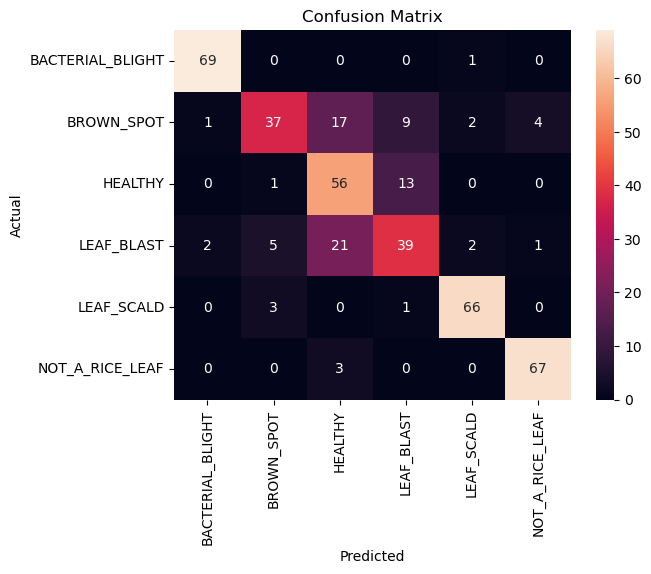

In [42]:
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Sample predictions and misclassifications**

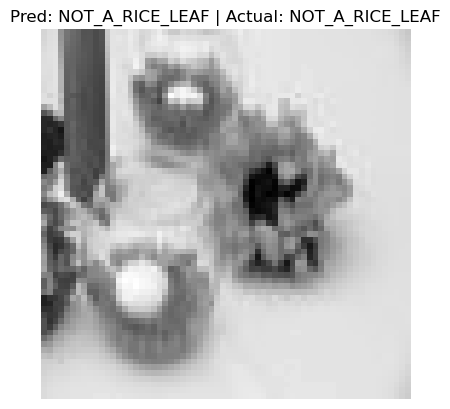

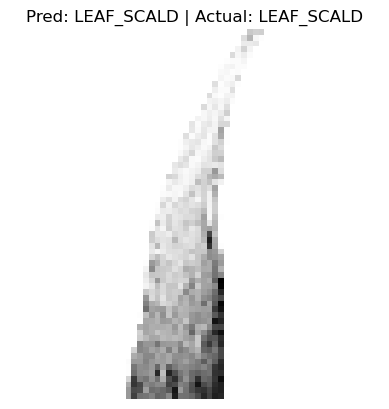

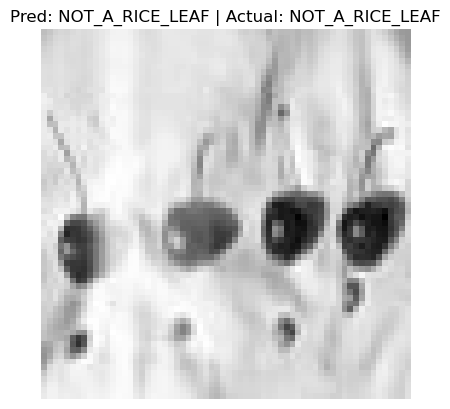

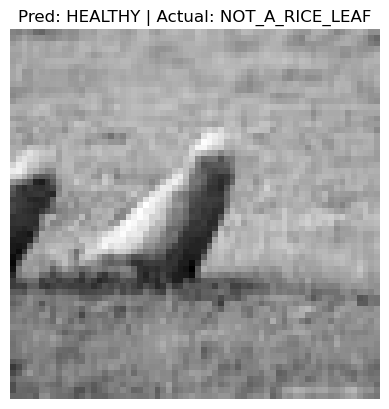

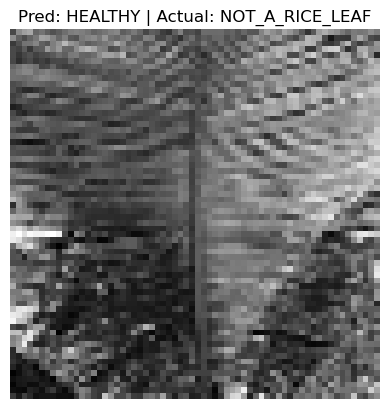

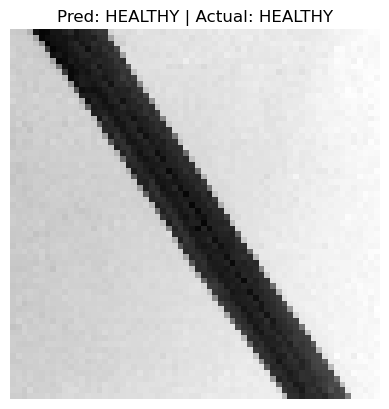

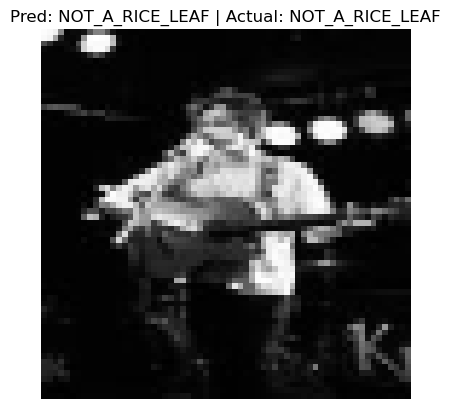

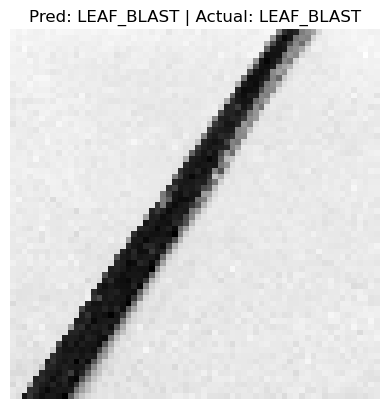

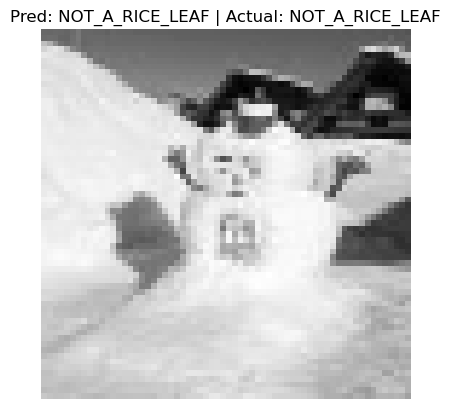

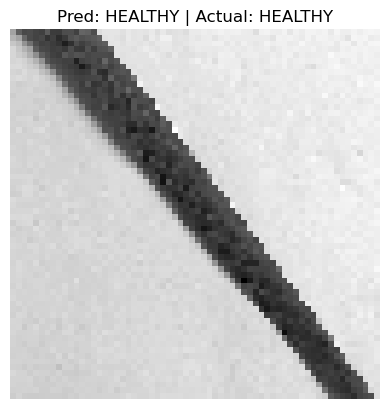

In [43]:
indices = random.sample(range(len(X_test)), 10)

for i in indices:
    plt.figure()
    plt.imshow(images_test[i], cmap='gray')
    plt.title(f"Pred: {le.classes_[y_pred[i]]} | Actual: {le.classes_[y_test[i]]}")
    plt.axis('off')
    plt.show()

# Part 3 (Testing) #

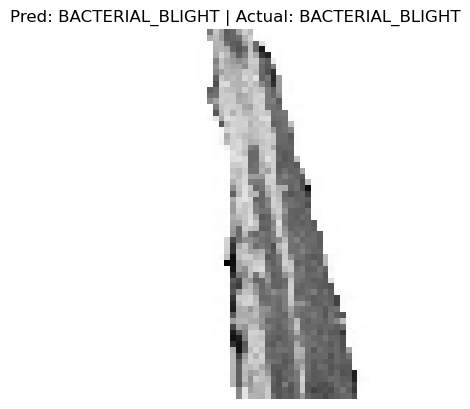

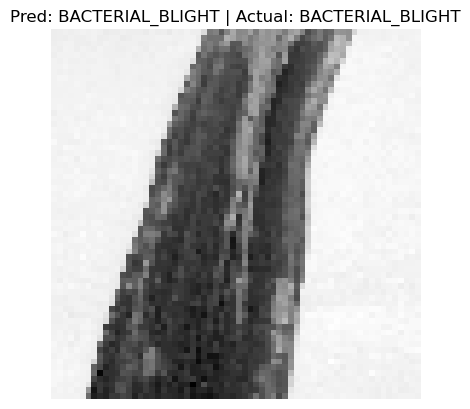

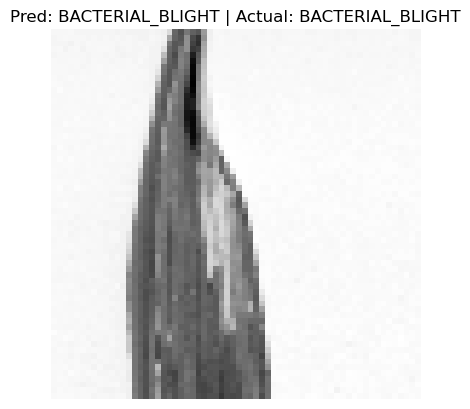

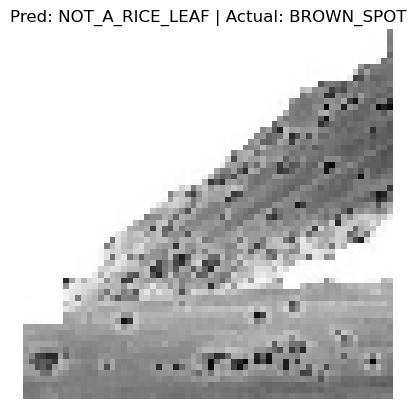

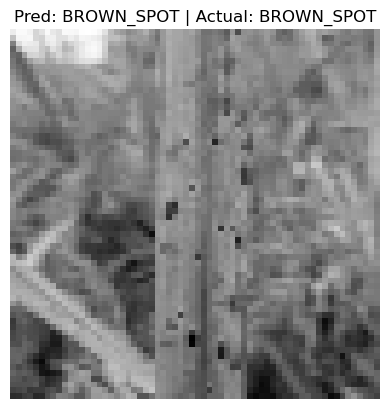

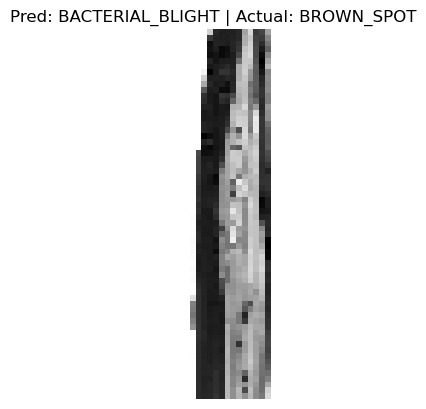

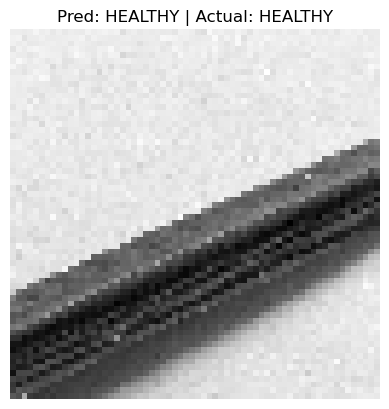

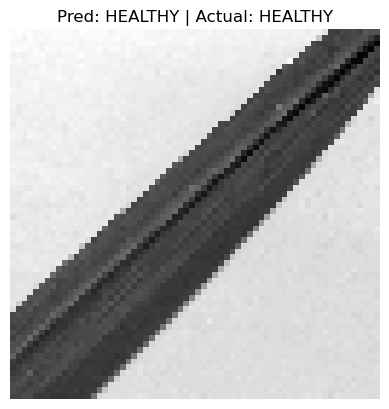

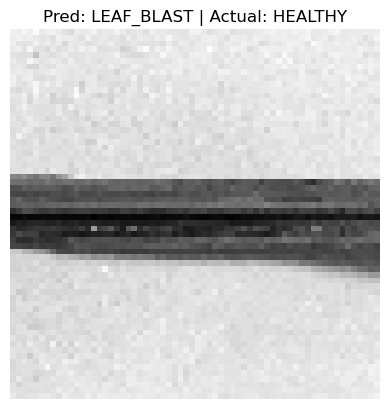

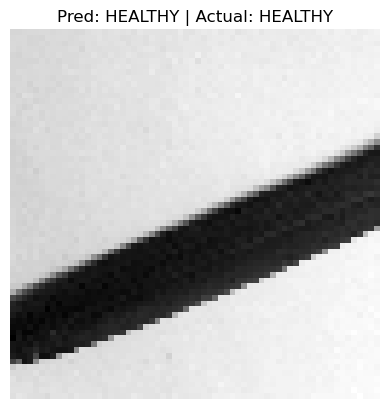

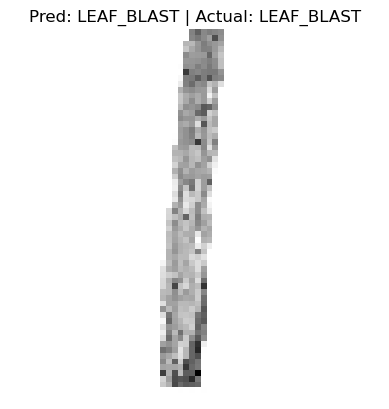

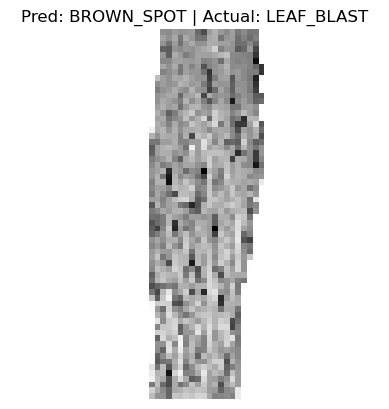

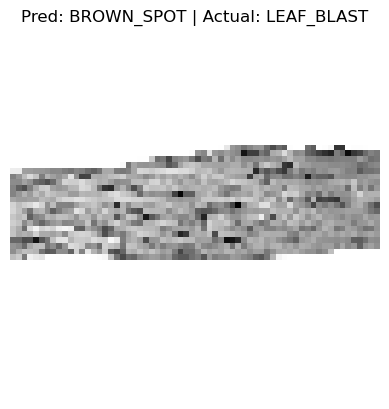

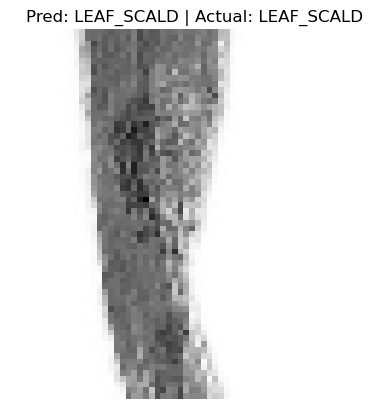

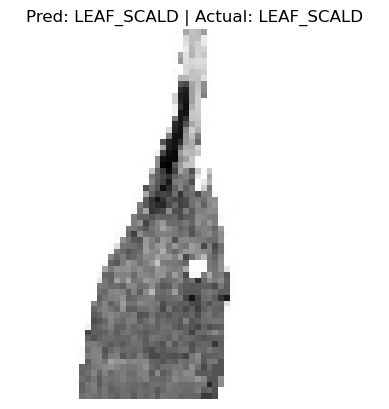

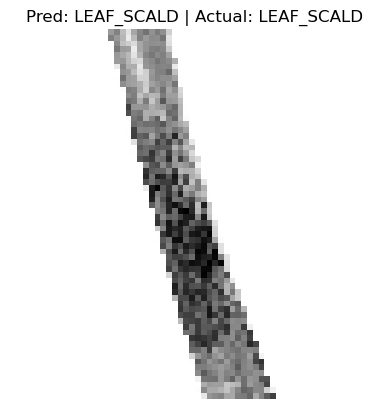

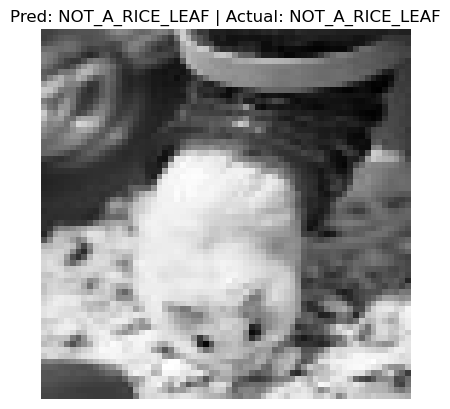

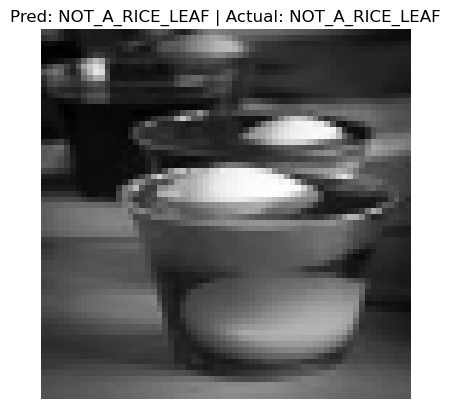

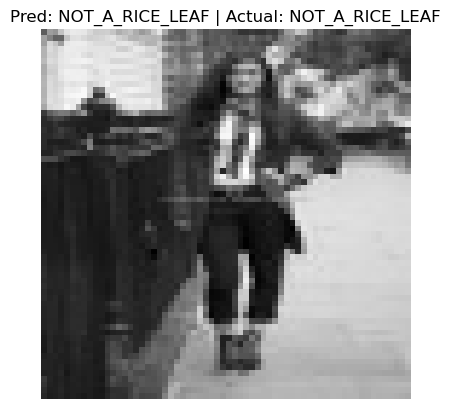

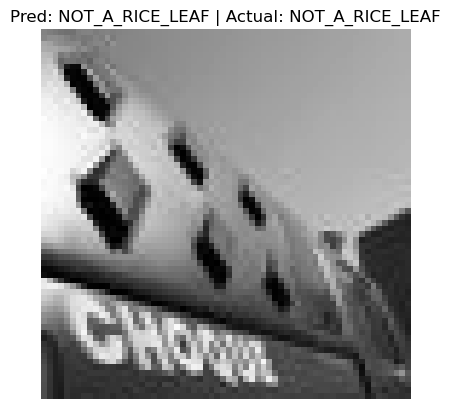

In [44]:
# Test model with 20 new images
def extract_label(filename):
    return "_".join(filename.split("_")[:-1])

def predict_external_image(img_path):
    img = cv2.imread(img_path, 0)
    
    if img is None:
        return None, None
    
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    
    features = hog(img, pixels_per_cell=(4,4), cells_per_block=(2,2))
    features = features.reshape(1, -1)
    
    features = scaler.transform(features)
    
    pred = model.predict(features)
    label = le.classes_[pred[0]]
    
    return label, img

# Test external folder
test_folder = "TEST_RICE_IMAGES"

for file in os.listdir(test_folder):
    if not file.lower().endswith((".jpg", ".png", ".jpeg")):
        continue
    
    img_path = os.path.join(test_folder, file)
    
    pred_label, img = predict_external_image(img_path)
    
    if pred_label is None:
        continue
    
    actual_label = extract_label(file)
       
    plt.imshow(img, cmap='gray')
    plt.title(f"Pred: {pred_label} | Actual: {actual_label}")
    plt.axis('off')
    plt.show()

# Model Export #

In [45]:
# Save classification model using pickle
with open("svm_rice_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save scaler model
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)